In [3]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage.filters import threshold_otsu
from skimage.morphology import skeletonize

folder = Path(r"C:\Users\taylorhearn\Dropbox\Diagrams\Affinity_pics\fd")
png_files = sorted(folder.glob("*.png"))

if len(png_files) < 4:
    raise ValueError(f"Expected at least 4 PNG files in {folder}, found {len(png_files)}")

png_files = png_files[:4]

def fractal_dimension_and_lacunarity(binary_image: np.ndarray) -> tuple[float, float]:
    img = binary_image.astype(bool)
    if not np.any(img):
        return np.nan, np.nan

    min_dim = min(img.shape)
    max_power = int(np.floor(np.log2(min_dim)))
    sizes = 2 ** np.arange(max_power, 1, -1)

    counts = []
    valid_sizes = []
    lac_values = []

    for size in sizes:
        h, w = img.shape
        h_crop = (h // size) * size
        w_crop = (w // size) * size
        if h_crop == 0 or w_crop == 0:
            continue

        cropped = img[:h_crop, :w_crop]
        blocks = cropped.reshape(h_crop // size, size, w_crop // size, size)

        occupied = blocks.any(axis=(1, 3))
        count = np.count_nonzero(occupied)
        if count > 0:
            counts.append(count)
            valid_sizes.append(size)

        masses = blocks.sum(axis=(1, 3)).astype(np.float64).ravel()
        nonzero_masses = masses[masses > 0]
        if nonzero_masses.size > 1:
            mean_mass = nonzero_masses.mean()
            var_mass = nonzero_masses.var()
            lac = (var_mass / (mean_mass ** 2)) + 1.0
            lac_values.append(lac)

    if len(counts) < 2:
        fd = np.nan
    else:
        coeffs = np.polyfit(np.log(1 / np.array(valid_sizes)), np.log(np.array(counts)), 1)
        fd = float(coeffs[0])

    lacunarity = float(np.mean(lac_values)) if lac_values else np.nan
    return fd, lacunarity

skeletons = []
fractal_dims = []
lacunarities = []
names = []

for file_path in png_files:
    gray = np.array(Image.open(file_path).convert("L"), dtype=np.float32)

    try:
        t = threshold_otsu(gray)
    except ValueError:
        t = float(np.mean(gray))

    binary = gray > t
    skeleton = skeletonize(binary)

    fd, lac = fractal_dimension_and_lacunarity(skeleton)

    skeletons.append(skeleton)
    fractal_dims.append(fd)
    lacunarities.append(lac)
    names.append(file_path.name)

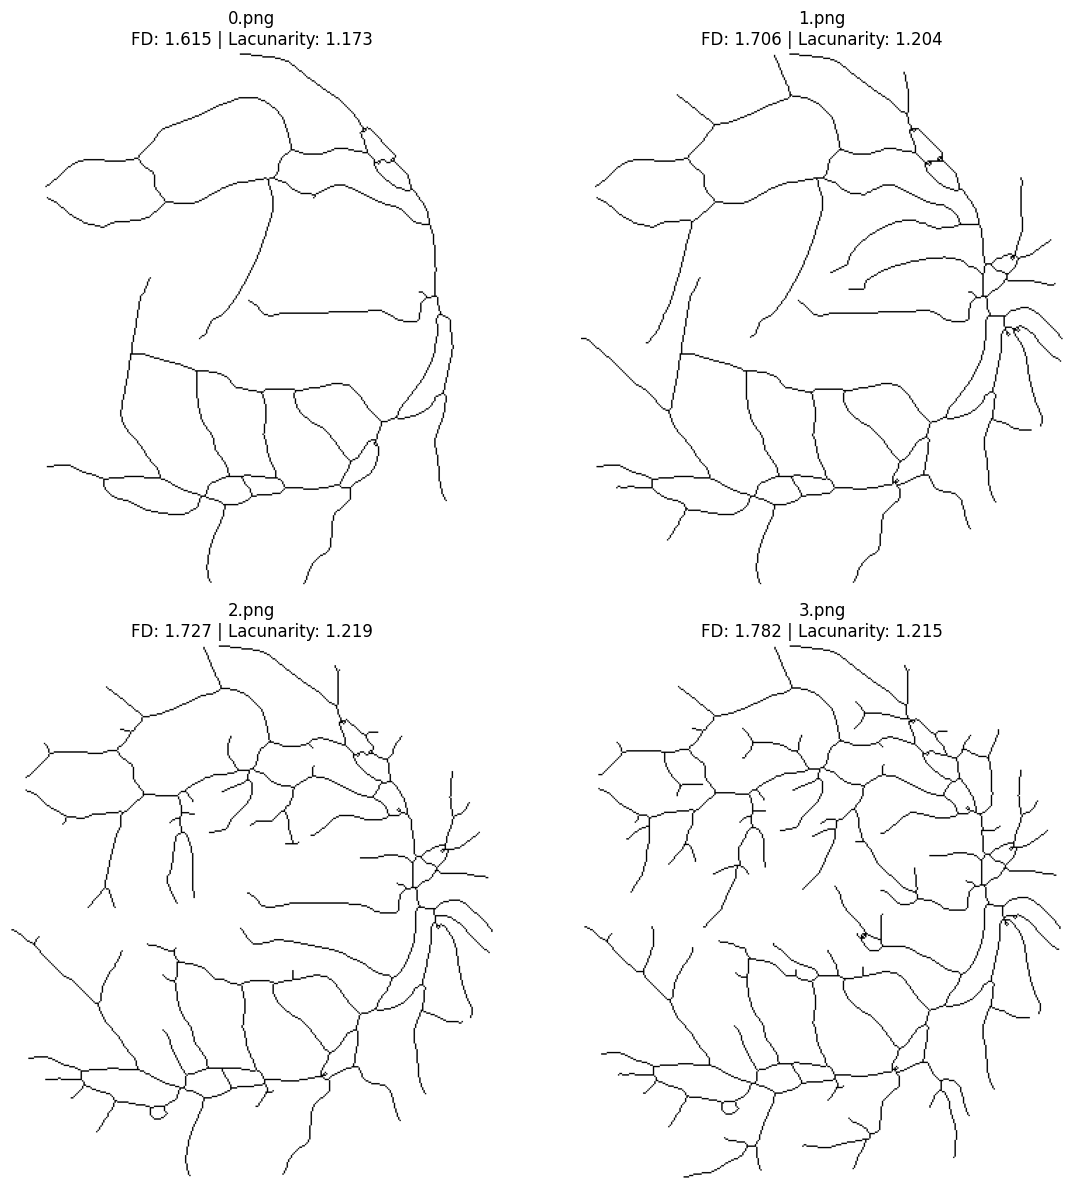

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.ravel()
from skimage import util

for i, ax in enumerate(axes):
    ax.imshow(util.invert(skeletons[i]), cmap="gray")
    fd_text = f"{fractal_dims[i]:.3f}" if np.isfinite(fractal_dims[i]) else "NaN"
    lac_text = f"{lacunarities[i]:.3f}" if np.isfinite(lacunarities[i]) else "NaN"
    ax.set_title(f"{names[i]}\nFD: {fd_text} | Lacunarity: {lac_text}")
    ax.axis("off")

plt.tight_layout()
plt.savefig("FD_lacunarity.pdf")
plt.show()